In [5]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
from scipy.stats import levene
from scipy.stats import shapiro
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [7]:
df_1 = pd.read_csv('Bank Customer Churn Prediction.csv')
df = df_1.copy()

# Task 1: One-Way ANOVA
Split the outcome variable into separate arrays (or use a groupby), one per level of the grouping variable.
Run a one-way ANOVA using scipy.stats.f_oneway.
Record the F-statistic and p-value.
In a markdown cell, interpret the result:
State the null and alternative hypotheses in plain language.
Based on the p-value (use α = 0.05), do you reject or fail to reject the null?
What does the F-statistic tell you about the ratio of between-group to within-group variance?

In [9]:
# Split data into groups by country
groups = df.groupby('country')['balance'].apply(list)
# Extract arrays
group_list = [group for group in groups]
# Run ANOVA
F_stat, p_value = f_oneway(*group_list)

print("F-statistic:", F_stat)
print("p-value:", p_value)

F-statistic: 958.4254463368385
p-value: 0.0


The one-way ANOVA test was used to check if the mean balance differs across countries.
The null hypothesis states that all countries have the same mean balance, while the alternative states that at least one country is different.
Since the p-value (0.0) is less than 0.05, we reject the null hypothesis. This means there is a significant difference in mean balance between countries.
The very high F-statistic (958.43) shows that the variation between countries is much larger than the variation within each country, indicating a strong group effect.

# Task 2: Check ANOVA Assumptions
ANOVA results are only reliable when two key assumptions hold. Test both here.

Homogeneity of variance (Levene's test):

Run scipy.stats.levene on the same groups.
Report the test statistic and p-value.
Interpret: is the equal-variance assumption reasonable?
Normality of residuals:

For each group, run the Shapiro-Wilk test (scipy.stats.shapiro).
Alternatively, compute the ANOVA residuals (observed − group mean) and run Shapiro-Wilk on the pooled residuals.
Create a Q-Q plot of the residuals (use scipy.stats.probplot or statsmodels.graphics.gofplots.qqplot).
In a markdown cell, summarize:
Do the residuals look approximately normal?
If either assumption is violated, what alternatives could you use (e.g., Welch's ANOVA, Kruskal-Wallis)?

In [12]:
# same groups from Task 1
groups = df.groupby('country')['balance'].apply(list)
group_list = [group for group in groups]
# Levene test
stat, p = levene(*group_list)

print("Levene statistic:", stat)
print("p-value:", p)

Levene statistic: 3344.1395541762836
p-value: 0.0


In [14]:
# Compute residuals
df['group_mean'] = df.groupby('country')['balance'].transform('mean')
df['residuals'] = df['balance'] - df['group_mean']
# Shapiro test on residuals
stat, p = shapiro(df['residuals'])

print("Shapiro statistic:", stat)
print("p-value:", p)

Shapiro statistic: 0.8830529480378982
p-value: 1.9114263944119057e-65


C:\Users\royan\anaconda3\envs\data_analysis\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.
  res = hypotest_fun_out(*samples, **kwds)


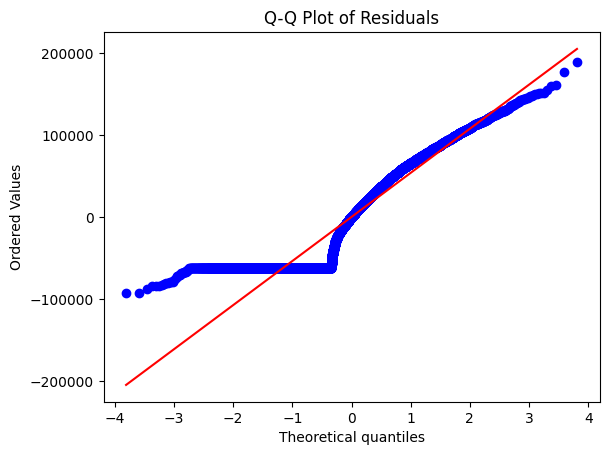

In [16]:
stats.probplot(df['residuals'], dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

Levene’s test shows a p-value of 0.0, which is less than 0.05, so the equal variance assumption is violated. This means the variances across countries are not equal.
The Shapiro-Wilk test also gives a very small p-value, indicating that the residuals are not normally distributed. This is supported by the Q-Q plot, where the points clearly deviate from the straight line, especially in the tails.
Since both assumptions are violated, the ANOVA results may not be fully reliable. In this case, alternative methods such as **Welch’s ANOVA** (for unequal variances) or the **Kruskal-Wallis test** (for non-normal data) would be more appropriate.


# Task 3: Tukey HSD Post-Hoc Comparisons
The overall ANOVA F-test tells you that at least one group differs, but not which groups differ. Post-hoc tests fill that gap.

Run Tukey's HSD test using statsmodels.stats.multicomp.pairwise_tukeyhsd.
Print the results table showing each pairwise comparison, the mean difference, the confidence interval, and the reject/fail-to-reject decision.
Create a mean plot with confidence intervals (Tukey's HSD provides these) to visualize which groups overlap.
In a markdown cell, answer:
Which specific group pairs have significantly different means?
Which pairs are not significantly different?
Do the confidence intervals help you understand the practical size of the differences?

In [19]:
# Run Tukey test
tukey = pairwise_tukeyhsd(
    endog=df['balance'],
    groups=df['country'],
    alpha=0.05
)
print(tukey)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
 group1  group2   meandiff  p-adj     lower       upper    reject
-----------------------------------------------------------------
 France Germany  57637.4796    0.0  54360.7642   60914.195   True
 France   Spain   -274.4888 0.9791  -3565.2806   3016.3031  False
Germany   Spain -57911.9684    0.0 -61707.2892 -54116.6476   True
-----------------------------------------------------------------


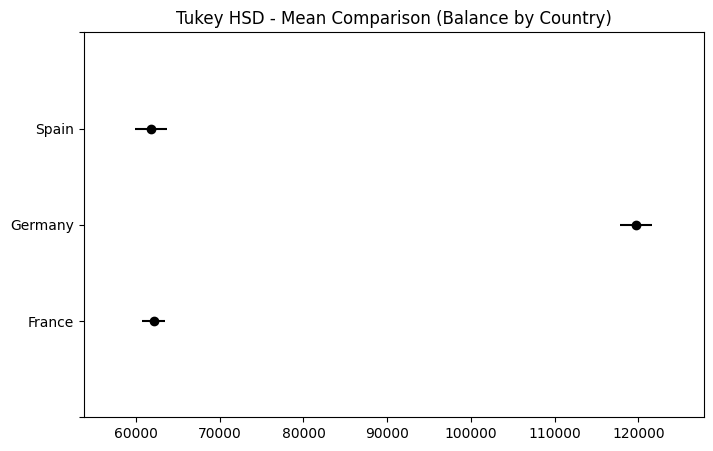

In [21]:
tukey.plot_simultaneous(figsize=(8,5))
plt.title("Tukey HSD - Mean Comparison (Balance by Country)")
plt.show()

The Tukey HSD test was used to identify which country pairs have significantly different mean balances.

The results show that:  
France and Germany have significantly different means (reject = True)  
Germany and Spain also have significantly different means (reject = True)  
France and Spain do not have a significant difference (reject = False)  

This means that Germany’s average balance is significantly different from both France and Spain, while France and Spain have similar mean balances.
The confidence intervals support these findings. For the significant pairs, the intervals do not include zero, indicating a clear difference in means. For France and Spain, the interval includes zero, showing that the difference is not statistically significant.
Overall, the confidence intervals help understand not only whether the differences are significant but also how large those differences are in practice.